# 1. **Reading Data**

In [2]:
import pandas
import numpy
import matplotlib
import sklearn
import seaborn
import statsmodels

In [3]:
import sys
!{sys.executable} -m pip install statsmodels

In [4]:

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
#from google.colab import drive

In [5]:

df = pd.read_csv('loan_dataset.csv')
print( df.shape )

(32586, 13)


Dataset taken from https://www.kaggle.com/datasets/prakashraushan/loan-dataset

Important information about dataset, as per link:

"Loan Default Prediction Dataset

This dataset contains information about customer loans, including customer demographics, loan details, and default status. The dataset can be used for various data analysis and machine learning tasks, such as predicting loan default risk. The dataset consists of the following columns:

customer_id: Unique identifier for each customer

customer_age: Age of the customer

customer_income: Annual income of the customer

home_ownership: Home ownership status (e.g., RENT, OWN, MORTGAGE)

employment_duration: Duration of employment in months

loan_intent: Purpose of the loan (e.g., PERSONAL, EDUCATION, MEDICAL, VENTURE)

loan_grade: Grade assigned to the loan

loan_amnt: Loan amount requested

loan_int_rate: Interest rate of the loan

term_years: Loan term in years

historical_default: Indicates if the customer has a history of default (Y/N)

cred_hist_length: Length of the customer's credit history in years

Current_loan_status: Current status of the loan (DEFAULT, NO DEFAULT)

Some extra details:

TARGET VALUE is Current Loan Status. Binary: Default, and no Default. Default = True and No Default = False. Use other attributes to predict loan status.

Different data types (nominal, ordinal, ratio, etc).

Contains Missing Values

Has a lot of quirks to it. Data definitely needs to be cleaned before use

Example: Loan amount column has '£' and ',' symbols, so instead of being numerical it is a string. That needs to be removed


# 2. **Cleaning Data**

In [6]:
#looking at datatypes for each column
for x in df.columns:
  print( str( type( df[x].iloc[0] ) ) + ": " + x )

<class 'numpy.float64'>: customer_id
<class 'numpy.int64'>: customer_age
<class 'str'>: customer_income
<class 'str'>: home_ownership
<class 'numpy.float64'>: employment_duration
<class 'str'>: loan_intent
<class 'str'>: loan_grade
<class 'str'>: loan_amnt
<class 'numpy.float64'>: loan_int_rate
<class 'numpy.int64'>: term_years
<class 'float'>: historical_default
<class 'numpy.int64'>: cred_hist_length
<class 'str'>: Current_loan_status


In [7]:
df.count()

customer_id            32583
customer_age           32586
customer_income        32586
home_ownership         32586
employment_duration    31691
loan_intent            32586
loan_grade             32586
loan_amnt              32585
loan_int_rate          29470
term_years             32586
historical_default     11849
cred_hist_length       32586
Current_loan_status    32582
dtype: int64

*Some of these columns having missing values*

* Employment_Duration, loan_amnt, loan_int_rate, and historical_default

I've already chosen to replace null values with mean for employment duration and loan int rate

Historical default has an extremely large number of missing values because it's only applicable to customers who's current loan status is DEFAULT. Instead of making it binary I'm just gonna make it 3 options: the null value will elicit a third option (either 0 or 2).



1.1 Convert Categorical to Numeric

In [8]:
# First converting categories to numerical values so I can run models
from sklearn.preprocessing import LabelEncoder
df['Current_loan_status'] = df['Current_loan_status'].replace('DEFAULT', 1)
df['Current_loan_status'] = df['Current_loan_status'].replace('NO DEFAULT', 0)
df['Current_loan_status'] = df['Current_loan_status'].fillna(0)
categories = ['home_ownership', 'loan_intent', 'historical_default']
for feature in categories:
    # create a fresh encoder for each feature
    df[feature] = LabelEncoder().fit_transform(df[feature].astype(str))

print(df)
# Nominal data

       customer_id  customer_age customer_income  home_ownership  \
0              1.0            21            9600               2   
1              2.0            22           59000               3   
2              3.0            25            9600               0   
3              4.0            23           65500               3   
4              5.0            24           54400               3   
...            ...           ...             ...             ...   
32581      32577.0            57           53000               0   
32582      32578.0            54          120000               0   
32583      32579.0            65           76000               3   
32584      32580.0            56          150000               0   
32585      32581.0            99           42000               3   

       employment_duration  loan_intent loan_grade   loan_amnt  loan_int_rate  \
0                      5.0            1          A   £1,000.00          11.14   
1                    

In [9]:
df['Current_loan_status'] = df['Current_loan_status'].astype(int)

print(df['Current_loan_status'].dtype)
print(df['Current_loan_status'].unique())

int64
[0 1]


In [10]:
# For Loan_grade column, I want to preserve its ordinal nature so use OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
df['loan_grade'] = encoder.fit_transform(df[['loan_grade']])
print(df['loan_grade'])

# A = 0, b = 1, etc.


0        0.0
1        2.0
2        1.0
3        1.0
4        1.0
        ... 
32581    2.0
32582    0.0
32583    1.0
32584    1.0
32585    1.0
Name: loan_grade, Length: 32586, dtype: float64


Checking now the types of our variables, they either need to be int64 or float64

In [11]:
print(df.dtypes)

customer_id            float64
customer_age             int64
customer_income            str
home_ownership           int64
employment_duration    float64
loan_intent              int64
loan_grade             float64
loan_amnt                  str
loan_int_rate          float64
term_years               int64
historical_default       int64
cred_hist_length         int64
Current_loan_status      int64
dtype: object


customer_income and loan_amt are both str, customer_income needs to be int and loan_amt needs to be float

In [12]:
# Now to remove the '£' and ',' symbols from the loan amount column

df['loan_amnt'] = df['loan_amnt'].str.replace('£', '')
df['loan_amnt'] = df['loan_amnt'].str.replace(',', '')
df['loan_amnt'] = df['loan_amnt'].astype(float)

# I also had to do this with customer_income because there was ONE row that had a comma in it.
# That took me a long time to notice

df['customer_income'] = df['customer_income'].str.replace(',', '')
df['customer_income'] = df['customer_income'].astype(int)

df['loan_amnt']

0         1000.0
1        35000.0
2         5500.0
3        35000.0
4        35000.0
          ...   
32581     5800.0
32582    17625.0
32583    35000.0
32584    15000.0
32585     6475.0
Name: loan_amnt, Length: 32586, dtype: float64

Now to address missing values


Need to fill in Employment_Duration, loan_amnt, loan_int_rate,

The link where I got the dataset from didn't specify why there were missing values for certain columns, so I'm gonna have to make some (reasonable) assumptions and work from there.

FOR EMPLOYMENT DURATION: I was thinking that null value meant 0, but there are actual 0 values in the column, so that can't be it. Therefore, I'm gonna assume that that data was simply unavailable, and replace the null values with the mean value

FOR LOAN AMOUNT: The loan amount is the loan amount *requested by customer, not the approved loan amount. I'm gonna assume that the missing values represent unspecified loan amount values for whatever reason
and replace them with the mean values.

FOR LOAN INT RATE: There are no 0 values, so the loans with a null loan_int_rate are no-interest loans
which do exist. So these null values can be replaced with 0.

FOR CURRENT LOAN STATUS: I noticed that there were 4 missing values. I handled this issue earlier when setting the dataframe to binary 0 and 1, and I simply filled in the null values with No Default, because that is the most common outcome (79%).

In [13]:
df['employment_duration'] = df['employment_duration'].fillna(df['employment_duration'].mean())
df['loan_amnt'] = df['loan_amnt'].fillna(df['loan_amnt'].mean())
df['loan_int_rate'] = df['loan_int_rate'].fillna(0)

df.count()

customer_id            32583
customer_age           32586
customer_income        32586
home_ownership         32586
employment_duration    32586
loan_intent            32586
loan_grade             32586
loan_amnt              32586
loan_int_rate          32586
term_years             32586
historical_default     32586
cred_hist_length       32586
Current_loan_status    32586
dtype: int64


As a side note, Customer_id has 3 missing values, which is strange. I'm not sure why that's the case, but it's not included in the dataframe because it's not gonna be relevant for the models anyway.

**Exploratory Analysis**: I want to see how the variables interact with each other, and which variables matter. I want to do some feature selection based off this, omitting features, potentially combining features.

In [14]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,21,9600,2,5.0,1,0.0,1000.0,11.14,1,2,2,0
1,2.0,22,59000,3,123.0,4,2.0,35000.0,16.02,10,1,3,1
2,3.0,25,9600,0,1.0,3,1.0,5500.0,12.87,5,0,3,1
3,4.0,23,65500,3,4.0,3,1.0,35000.0,15.23,10,0,2,1
4,5.0,24,54400,3,8.0,3,1.0,35000.0,14.27,10,1,4,1


In [15]:
df.describe()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
count,32583.000000,32586.000000,3.258600e+04,32586.000000,32586.000000,32586.000000,32586.000000,3.258600e+04,32586.000000,32586.000000,32586.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,6.607637e+04,1.676425,4.790161,2.533726,0.860001,9.756247e+03,9.958585,4.761738,1.460811,5.804026,0.209906
std,9405.919628,6.360528,6.198029e+04,1.433099,4.085456,1.731115,1.009535,2.177152e+04,4.470203,2.471107,0.774348,4.055078,0.407248
min,1.000000,3.000000,4.000000e+03,0.000000,0.000000,0.000000,0.000000,5.000000e+02,0.000000,1.000000,0.000000,2.000000,0.000000
25%,8144.500000,23.000000,3.850000e+04,0.000000,2.000000,1.000000,0.000000,5.000000e+03,7.490000,3.000000,1.000000,3.000000,0.000000
50%,16288.000000,26.000000,5.500000e+04,3.000000,4.000000,3.000000,1.000000,8.000000e+03,10.620000,4.000000,2.000000,4.000000,0.000000
75%,24433.500000,30.000000,7.920000e+04,3.000000,7.000000,4.000000,1.000000,1.220000e+04,13.110000,7.000000,2.000000,8.000000,0.000000
max,32581.000000,144.000000,6.000000e+06,3.000000,123.000000,5.000000,4.000000,3.500000e+06,23.220000,10.000000,2.000000,30.000000,1.000000


In [16]:
#double-checking to see if all data is numerical now
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  int64  
 3   home_ownership       32586 non-null  int64  
 4   employment_duration  32586 non-null  float64
 5   loan_intent          32586 non-null  int64  
 6   loan_grade           32586 non-null  float64
 7   loan_amnt            32586 non-null  float64
 8   loan_int_rate        32586 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   32586 non-null  int64  
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32586 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 3.2 MB


## 1.2 Visualization:

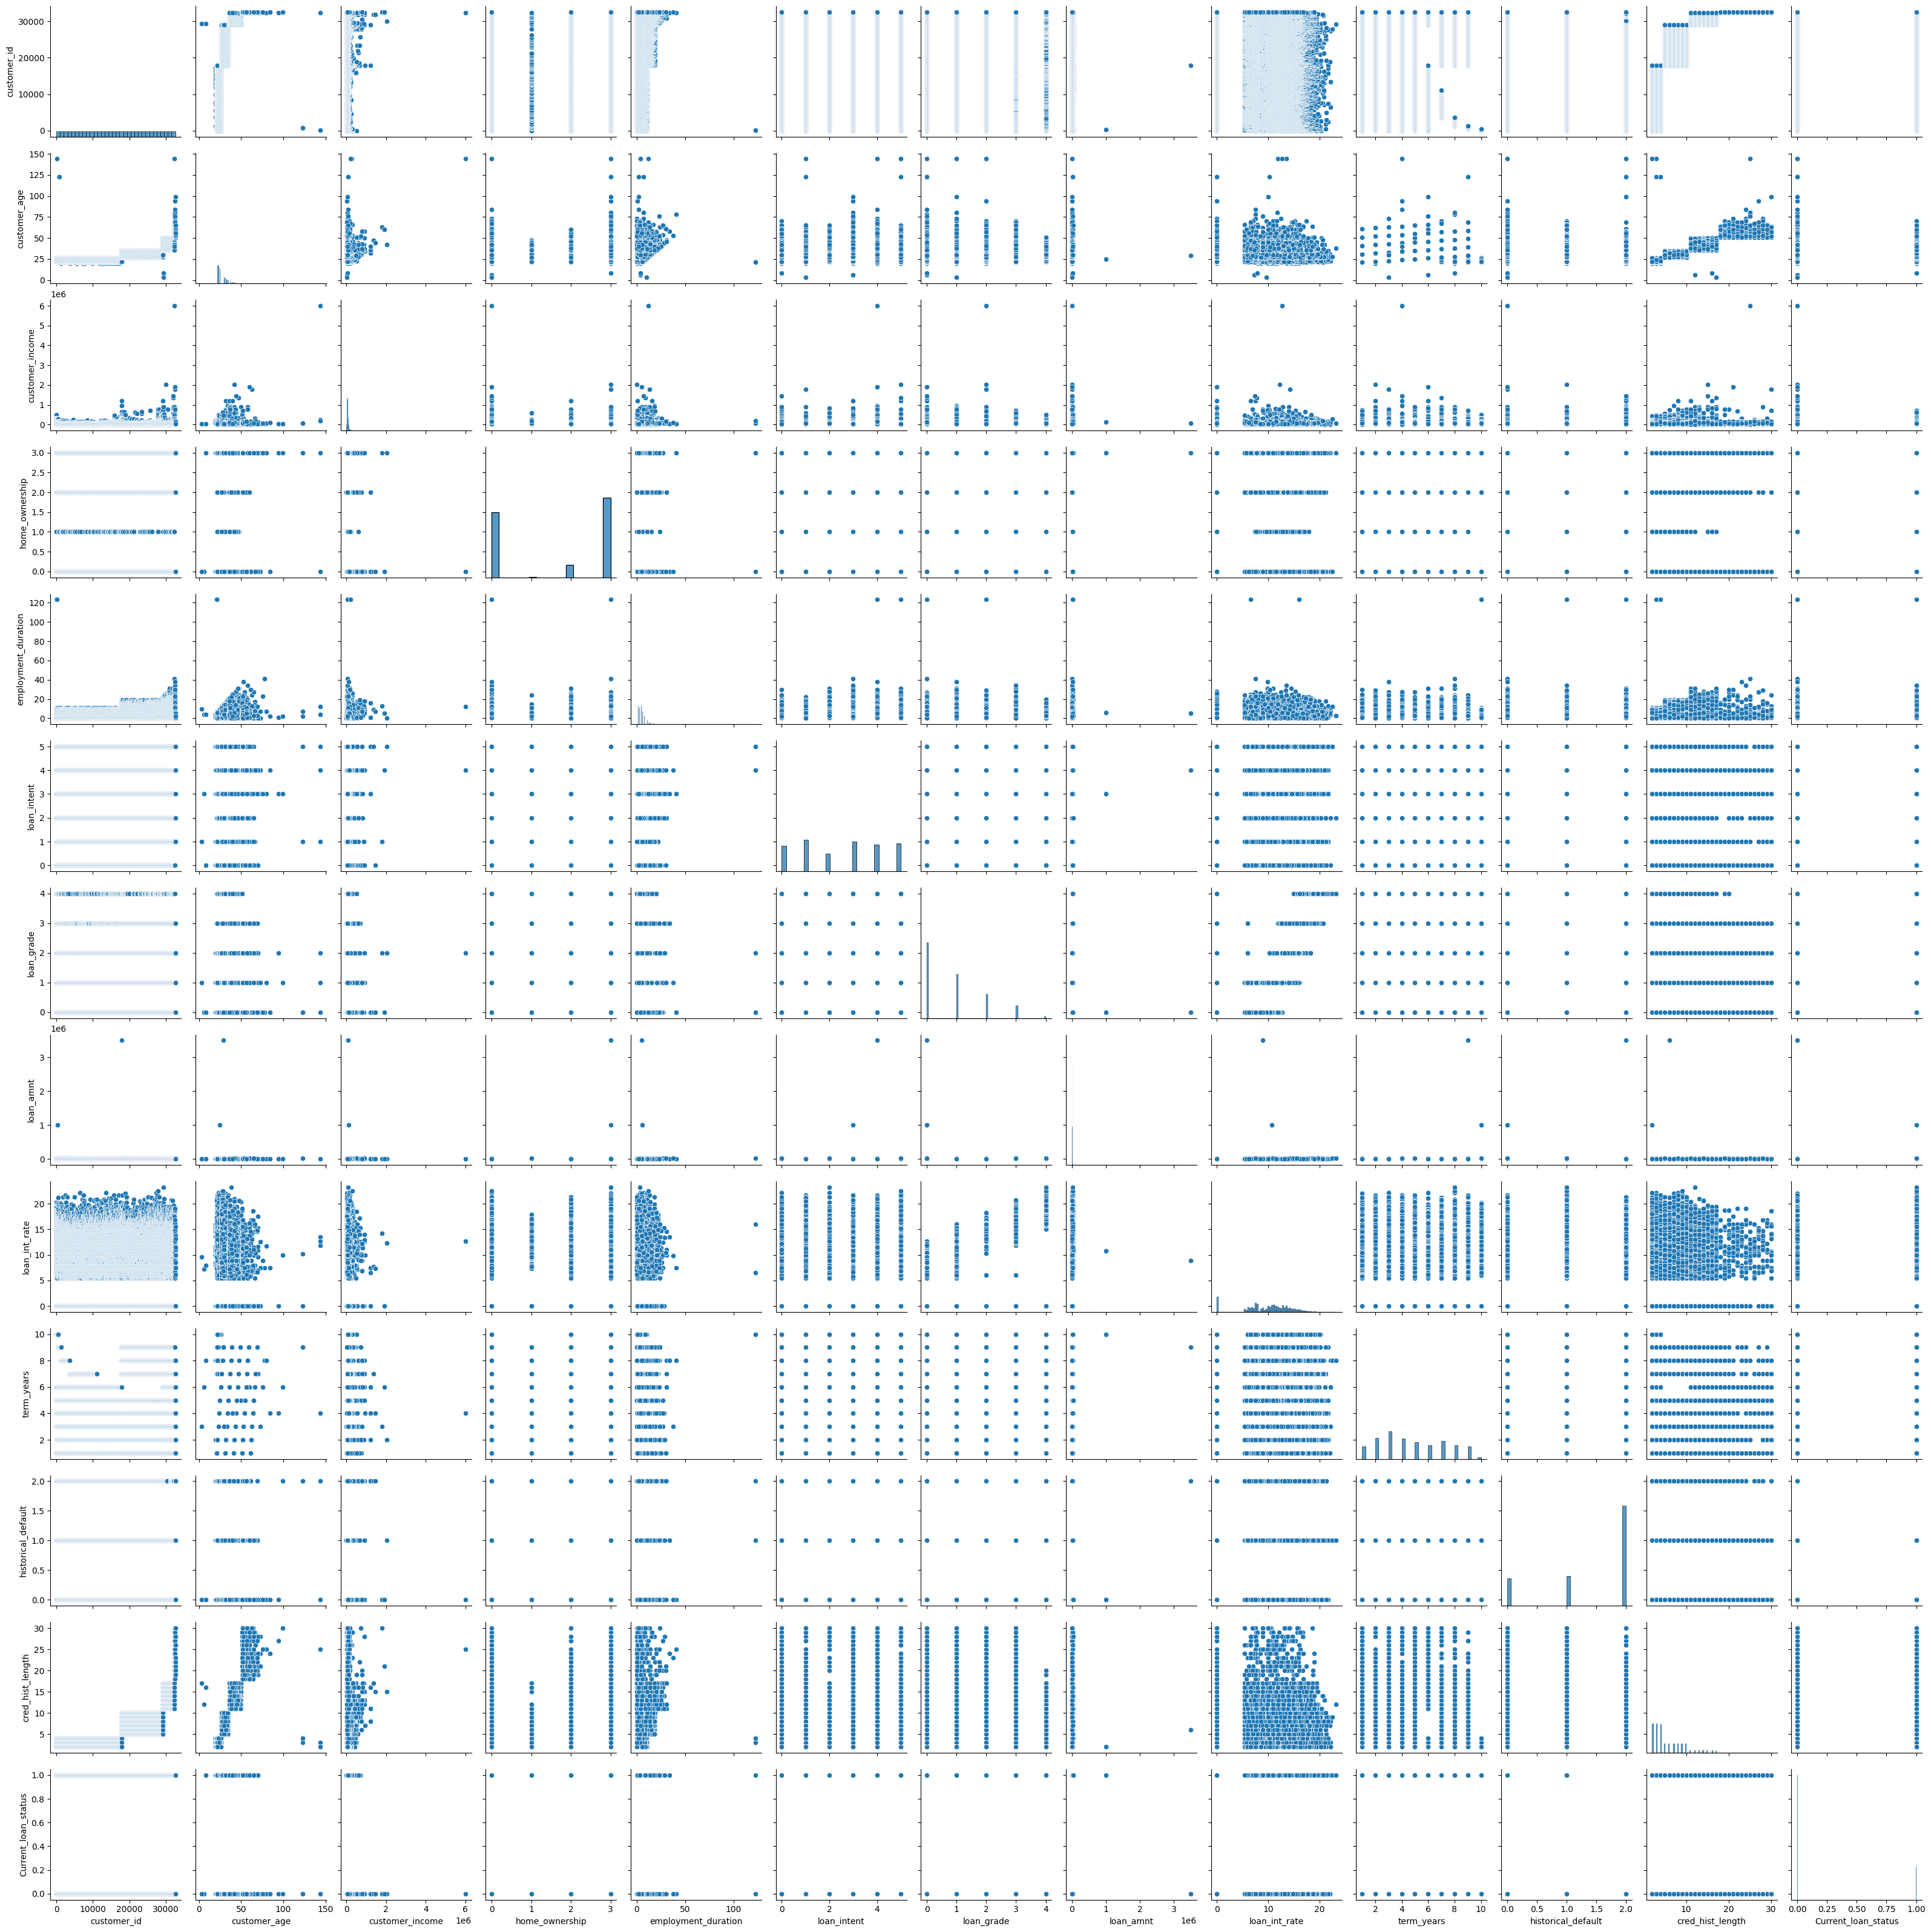

In [17]:
sns.pairplot(df)
plt.show()

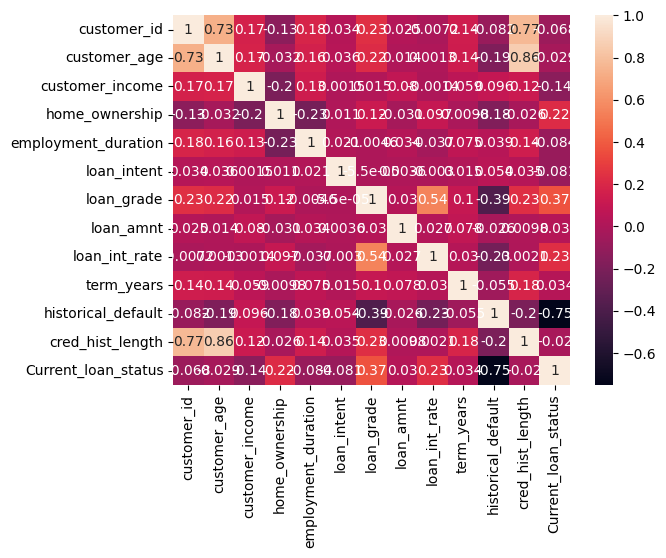

In [18]:
sns.heatmap(df.corr(), annot = True)
plt.show()

In [19]:
#Checking for correlations
correlation_matrix = df.corr()

print(np.round(correlation_matrix, 4))

                     customer_id  customer_age  customer_income  \
customer_id               1.0000        0.7325           0.1704   
customer_age              0.7325        1.0000           0.1731   
customer_income           0.1704        0.1731           1.0000   
home_ownership           -0.1296       -0.0320          -0.2031   
employment_duration       0.1842        0.1606           0.1334   
loan_intent               0.0344        0.0356           0.0015   
loan_grade                0.2344        0.2157           0.0153   
loan_amnt                 0.0254        0.0144           0.0802   
loan_int_rate            -0.0072        0.0013          -0.0014   
term_years                0.1436        0.1361           0.0595   
historical_default       -0.0823       -0.1879           0.0958   
cred_hist_length          0.7729        0.8575           0.1179   
Current_loan_status      -0.0679       -0.0290          -0.1406   

                     home_ownership  employment_duration  loa

In [20]:
# focusing on target variable
correlation_matrix['Current_loan_status'].sort_values(ascending = False)

Current_loan_status    1.000000
loan_grade             0.365358
loan_int_rate          0.229784
home_ownership         0.218865
term_years             0.033841
loan_amnt              0.029806
cred_hist_length      -0.019857
customer_age          -0.028981
customer_id           -0.067864
loan_intent           -0.081389
employment_duration   -0.084150
customer_income       -0.140624
historical_default    -0.751280
Name: Current_loan_status, dtype: float64

loan_grade, loan_int_rate_, home_ownership all have higher positive correlation

historical_default, customer_income negative correlation

loan_amnt, credit_hist_length, customer_age least important

**Feature Selection**: My first thought is to add another feature by multiply loan amount by interest rate and that by term years to get total interest cost.



In [21]:
#df['total_interest_cost'] = df['loan_amnt'] * df['loan_int_rate'] * df['term_years']

#df['total_interest_cost']

#This feature selection actually worsened the results, so I ended up not implementing this.


**Models:**
This is clearly a classification problem. I want to run KNN, Decision Trees, and Naive Bayes on it, but we'll see how that pans out. I also want to focus on visualization.

*Credits: I used some code from previous programming assignments to help me with these models, and I made adjustments to them.

Sklearn also helped me implement these models, particularly the pages for KNN and Decision Trees.
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html




Splitting data into test and train


In [22]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

#Gonna exclude historical_default for now
X = df.drop(['customer_id', 'historical_default', 'Current_loan_status'], axis = 1)
y = df['Current_loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size = 0.2, shuffle = True)

In [23]:
print(len(X_train),len(y_train),len(X_test),len(y_test))

26068 26068 6518 6518


In [24]:
print(X.head)

<bound method NDFrame.head of        customer_age  customer_income  home_ownership  employment_duration  \
0                21             9600               2                  5.0   
1                22            59000               3                123.0   
2                25             9600               0                  1.0   
3                23            65500               3                  4.0   
4                24            54400               3                  8.0   
...             ...              ...             ...                  ...   
32581            57            53000               0                  1.0   
32582            54           120000               0                  4.0   
32583            65            76000               3                  3.0   
32584            56           150000               0                  5.0   
32585            99            42000               3                  2.0   

       loan_intent  loan_grade  loan_amnt  lo

**KNN** 1st trial, using k values from 175 to 185, no historical_default


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

K = []
training = []
test = []
scores = {}

NEW: I should try 1-31 for k values 

For feature selection: I'm dropping id for obvious reasons.
I'm dropping historical_default for now because I don't know if it'll be good for the model.
There's just a lot of missing values that I had to replace for it. I'm gonna use it in the next KNN model.

In [26]:

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    training_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]


y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix: \n", cm)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision: ", precision)
print("Recall:  ", recall)
print("F1: ", f1)



Confusion Matrix: 
 [[4909  233]
 [ 846  530]]
Precision:  0.6946264744429882
Recall:   0.3851744186046512
F1:  0.49555867227676487


Looking at Precision, Recall and F1: Precision is decent, Recall and F1 is underwhelming

For this kind of dataset, Precision is much more important than recall

Think about context: If we approve a loan for a customer who will default (false positive), we can lose a lot of money

If we disprove a loan for a customer who won't default (false negative), we don't gain money, but we also don't lose money

In this case false negatives are not as damaging as false positives. So we really need to minimize false positives

Precision measures the accuracy of positive predictions, so precision needs to be very high for this kind of dataset. Recall doesn't matter as much.

With all of that considered, these numbers still aren't great. The precision, recall and F1 score should all be much higher.

I'm gonna try KNN with more k values to see if that helps at least a little




In [27]:
for keys, values in scores.items():
  print(keys, values)

1 [1.0, 0.8120589137772323]
2 [0.9028310572349241, 0.8278613071494323]
3 [0.8983427957649225, 0.8227984044185332]
4 [0.8737532607027774, 0.8324639459957042]
5 [0.8709912536443148, 0.830316047867444]
6 [0.8620530919134571, 0.8358392144829703]
7 [0.8610940616848243, 0.8344584228290887]
8 [0.8553398803130274, 0.8358392144829703]
9 [0.8553015191038822, 0.8386007977907334]
10 [0.8513119533527697, 0.8381405339061062]
11 [0.8518490102808041, 0.8375268487266032]
12 [0.8488568359674697, 0.8372200061368518]
13 [0.8482430566211447, 0.8364528996624732]
14 [0.8469004143010588, 0.8339981589444615]
15 [0.8460564676998619, 0.8324639459957042]
16 [0.8444452969157588, 0.8344584228290887]
17 [0.8449056314255026, 0.832003682111077]
18 [0.8441767684517416, 0.8332310524700829]
19 [0.8441767684517416, 0.8350721080085916]
20 [0.8431410158048182, 0.8347652654188401]
21 [0.8419901795304588, 0.8341515802393372]
22 [0.8419901795304588, 0.8364528996624732]
23 [0.8420669019487494, 0.8358392144829703]
24 [0.84080098

The accuracy of predictions is pretty good for these k values

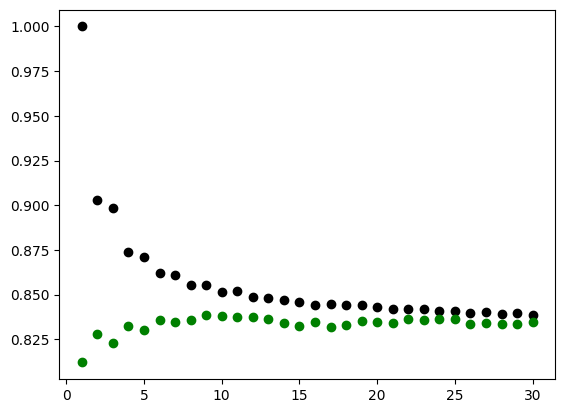

In [28]:
import matplotlib.pyplot as plt

plt.scatter(K, training, color = 'k')
plt.scatter(K, test, color = 'g')
plt.show()

All of these k values seem pretty good (just look at the y axis) but because we want an odd k value so there's no ties, For this I would go with k = 179.

KNN Trial Run #2

In [29]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Including historical_default now to see if that makes a difference
X = df.drop(['customer_id', 'Current_loan_status'], axis = 1)
y = df['Current_loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size = 0.2, shuffle = True)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

K = []
training = []
test = []
scores = {}

# I figured that instead of 10 k values I would experiment with 100 k values.
for k in range(135, 235 ):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    training_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]


y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix: \n", cm)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision: ", precision)
print("Recall:  ", recall)
print("F1: ", f1)


Confusion Matrix: 
 [[4936  206]
 [ 890  486]]
Precision:  0.7023121387283237
Recall:   0.35319767441860467
F1:  0.4700193423597679


So using 100 k values, we get a precision of .70 instead of .69, a .01 difference. Recall and F1 went down too. This took 4 minutes, so we're getting diminishing returns with this KNN model.
It appears that including historical_default didn't really affect the model either.

In [31]:
for keys, values in scores.items():
  print(keys, values)

135 [0.8316326530612245, 0.8344584228290887]
136 [0.8316710142703698, 0.8343050015342129]
137 [0.8319011815252417, 0.8343050015342129]
138 [0.8317477366886604, 0.8347652654188401]
139 [0.831824459106951, 0.8346118441239644]
140 [0.8317477366886604, 0.8346118441239644]
141 [0.8317477366886604, 0.8343050015342129]
142 [0.8313641245972073, 0.8344584228290887]
143 [0.8316326530612245, 0.8349186867137158]
144 [0.831325763388062, 0.8343050015342129]
145 [0.8317477366886604, 0.8344584228290887]
146 [0.8314408470154979, 0.8343050015342129]
147 [0.831325763388062, 0.8341515802393372]
148 [0.831325763388062, 0.83369131635471]
149 [0.8315175694337885, 0.8341515802393372]
150 [0.8311723185514808, 0.83369131635471]
151 [0.8313641245972073, 0.8335378950598343]
152 [0.8310955961331902, 0.8332310524700829]
153 [0.8311723185514808, 0.8333844737649586]
154 [0.830711984041737, 0.8333844737649586]
155 [0.8309805125057542, 0.8335378950598343]
156 [0.830711984041737, 0.8327707885854556]
157 [0.8311723185514

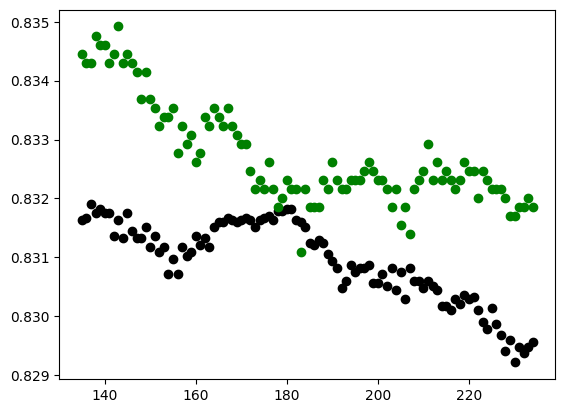

In [32]:
import matplotlib.pyplot as plt

plt.scatter(K, training, color = 'k')
plt.scatter(K, test, color = 'g')
plt.show()

Looking at this graph I can affirm my belief that the range around 180 appears to be ideal.

Looking at the two KNN models, I believe KNN might not be the right model for this problem

  KNN is better with smaller datasets, and this is a large dataset

  KNN uses a lot of memory, so it takes a lot of time to run compared to other models. So it's not great with experimentation, at least not in this case.
I'm gonna try another model and see where that takes us.

Decision Trees

I decided upon Decision Trees because from my knowlege, Decision Trees are well suited for larger datasets. The thing I have to watch out for is overfitting, which is a common issue with DT's.

I should also clarify that I'm not concerned about underfitting at all, because:

1. I have a lot of samples in the training set

2. The dataset has a lot of features. When I experimented with dropping some features, my scores would go down drastically, so that's why I avoided it


**These models include historical_default now.

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix as confusion_matrix_func, precision_score, recall_score, f1_score

decisionTree = DecisionTreeClassifier(max_depth = 10, random_state = 42  )

# Without setting max_depth equal to 10, I noticed that training would = 1. This indicates overfitting, so setting a max_Depth prevented this.
# Also noticed that without setting a max_depth, precision recall and F1 values would all be at around .71


decisionTree.fit(X_train, y_train)

path = decisionTree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

training_score = decisionTree.score(X_train, y_train)
test_score = decisionTree.score(X_test, y_test)

print( f'Train: {training_score}' )
print( f'Test: {test_score}' )

y_pred = decisionTree.predict(X_test)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix: \n", cm)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision: ", precision)
print("Recall:  ", recall)
print("F1: ", f1)



#Confusion Matrix of Decision Tree



Train: 0.9739911001994783
Test: 0.9601104633323105
Confusion Matrix: 
 [[5083   59]
 [ 201 1175]]
Precision:  0.9521880064829822
Recall:   0.8539244186046512
F1:  0.9003831417624522


*About Historical Default: when I excluded historical default from the dataframe for this model, these were the results:
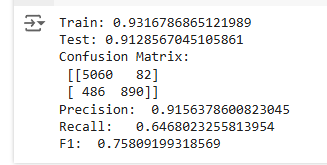

Not bad results, but the ones we got by including historical were much higher.
This shows that I handled the missing values from historical default well, and that including it in the dataframe is greatly beneficial for the CART model, but not for the KNN model.

Training and Test scores are great, at .97 and .96 respectively. I set a max_depth at 10, which prevented overfitting for training. When I didn't set a max_depth, the training was 1. That's bad because the training data gets memorized, essentially. So these values are great.

Precision at .95 is excellent, way better than the .69 or .70 from KNN. Also, I've avoided overfitting here as well! Recall at .85 is a big improvement from the .35 from KNN. and an F1 score of .90 is great.

What's most important is that precision is the highest. That is really important for this problem

I'm impressed by these results, but I'm gonna try to optimize this anyways.

I did some research and found that I could optimize precision and the F1 score at a cost of decreasing the training score by pruning the tree. I decided to implement this through sklearn's GridSearchCV. Essentially, I'm using cost complexity pruning (ccp) and finding the optimal alpha value (ccp_alpha) to get the optimal pruned tree. This can improve my results by increasing precision and F1. It can also lower the training data score, which is actually a good thing because it can be closer to the testing data score.

(https://www.geeksforgeeks.org/pruning-decision-trees/)

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(decisionTree, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_ccp_alpha = grid_search.best_params_['ccp_alpha']

In [35]:
prunedTree = DecisionTreeClassifier(ccp_alpha=best_ccp_alpha)
prunedTree.fit(X_train, y_train)

training_score = prunedTree.score(X_train, y_train)
test_score = prunedTree.score(X_test, y_test)

print( f'Train: {training_score}' )
print( f'Test: {test_score}' )

y_pred = prunedTree.predict(X_test)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix: \n", cm)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision: ", precision)
print("Recall:  ", recall)
print("F1: ", f1)

Train: 0.9696179223569127
Test: 0.9610309911015649
Confusion Matrix: 
 [[5088   54]
 [ 200 1176]]
Precision:  0.9560975609756097
Recall:   0.8546511627906976
F1:  0.9025326170376056


So by pruning the tree:

Precision went from .9521 to .9560, not a big difference but still welcome

Recall slight increase as well

F1 Score went from .9003 to 9025.

All at the cost of training score going from .97 to .96, which could be considered better because it's closer to the testing score, which is what we want.

Testing score also went up slightly

While all of these are minor changes, I think they still matter. Overall, this is my best model.

In [36]:
from sklearn import tree
import matplotlib.pyplot as plt



plt.figure(figsize=(100, 100))
tree.plot_tree(prunedTree)
plt.show()


Open in new image tab to view. Left is True, right is False.

In [37]:
from sklearn.metrics import accuracy_score
y_pred = prunedTree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9610309911015649


Great accuracy, we already saw this with the testing accuracy. The bottom line is that the test data accuracy should not be way below training data accuracy, because that would be overfitting.

If I had more time:
Would have experimented more with feature selection. Would have ran Naive Bayes and Logistic Regression to see how that would have worked.
Definitely would have experimented with Random Forest Trees. I read about that in the Ensemble slides and I viewed some videos about it. I plan on experimenting with it during winter break.